# Exercise 2: Regression


```{admonition} Run or download this notebook
:class: how-to-use

This page is fully readable as it is, and the interactive activity works
here in the browser. To **run or change the Python code**, use the portable
version of the notebook:

- **[Open the portable notebook in Colab](https://colab.research.google.com/github/yoavmp/ml-neuro-tutorials/blob/main/book/downloads/chapter_02/exercise_02_portable.ipynb)**
- **[View or download the portable `.ipynb`](https://raw.githubusercontent.com/yoavmp/ml-neuro-tutorials/main/book/downloads/chapter_02/exercise_02_portable.ipynb)**
  for VS Code or Jupyter

The portable notebook keeps every Python analysis cell and swaps the embedded
activity for a link back to this page.
```


## What this notebook covers

ABIDE's own research aim is autism-related group differences: comparing
autism and control participants on brain structure, and ultimately
supporting diagnosis and classification. Rich shared datasets like ABIDE can
also support other scientifically appropriate questions beyond that primary
aim, as long as the new question is stated honestly and not sold as
answering the original one. Here the target is **age**, a continuous
variable, so the task is **regression**: predicting a participant's age
from their cortical measurements. This notebook does not address autism
diagnosis or group differences -- that remains ABIDE's central question, not
this one.

This is Exercise 2 of *Machine Learning for Neuroscience*. Exercise 2 is about
**regression and the bias-variance tradeoff**. This practice covers the first
part: **linear regression on real neuroimaging data**. A later practice adds
k-nearest neighbours and the bias-variance tradeoff itself.

In this part you will:

1. load a wide *modelling table* -- FreeSurfer brain measurements for 1004
   ABIDE-II participants, with `age` as a native column;
2. build one honest linear-regression workflow: split, scale, fit on training
   data, predict held-out data, score it -- first with the scaling steps
   written out explicitly, then with the equivalent `scikit-learn` pipeline
   shortcut;
3. compare that honest score with the *training* score and with a deliberately
   *invalid* fit-on-the-test-set score, to see what "evaluation" can and cannot
   mean;
4. use a browser activity to compare feature sets side by side;
5. see what does -- and does not -- change as the sample gets smaller, all the
   way down to samples smaller than the number of features.

**Prerequisites:** the regression lecture; comfort with `pandas`, `numpy`,
`matplotlib`, and the scikit-learn `fit` / `predict` pattern.


## 1. The modelling table

Each **row is one participant**. The columns fall into three kinds:

- **phenotype columns** -- possible outcomes and context: `age`, `sex`, and
  diagnostic `group`;
- **brain columns** -- one FreeSurfer measurement (`fsCT` cortical thickness,
  `fsArea` surface area, `fsVol` grey-matter volume, `fsLGI` gyrification) for
  one cortical region of one hemisphere, e.g. `fsCT_L_46_ROI`. The regions are
  the 360 parcels of the HCP-MMP1 (Glasser) atlas;
- **identifiers** -- `subject`, `site`.

This exercise's outcome is **`age`**: it is a native column of the brain
table itself -- no join to another file is needed, and it has no missing
values for any of the 1004 participants.

This is a *modelling* table: wide, one measurement per column, ready for
`X` / `y`. It is not the small phenotype-only table from Exercise 1.


In [1]:
# Data loading. In the published book this cell is collapsed; it is plain,
# runnable Python -- one public CSV pinned to an immutable commit. Nothing
# here is repository-specific. `age` is a native column of this table, so no
# second file needs to be merged in for this notebook.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

PIN = "e4eed3c4daa7f40b0ba931182a8c7e5e691dba6b"
BASE = f"https://raw.githubusercontent.com/neurohackademy/nh2020-curriculum/{PIN}/tu-machine-learning-yarkoni/data"

model_df = pd.read_csv(f"{BASE}/abide2.tsv", sep="\t")
model_df = model_df.loc[:, [c for c in model_df.columns if not str(c).startswith("Unnamed")]]

BRAIN_COLS = [c for c in model_df.columns if c.startswith("fs")]
PHENO_COLS = ["age", "age_resid", "sex", "group"]
print(f"modelling table: {model_df.shape[0]} participants x {model_df.shape[1]} columns")


modelling table: 1004 participants x 1446 columns


In [2]:
# A compact look: the phenotype columns plus three representative brain columns,
# then a separate count summary. (Printing all 1446 columns would tell you
# nothing.)
def measure_of(col):
    return col.split("_")[0]          # fsCT, fsArea, fsVol, fsLGI

def roi_of(col):
    return col.split("_", 2)[2].rsplit("_ROI", 1)[0]   # "L_46" etc.

preview_cols = ["subject", "site", "group", "age", "sex",
                "fsCT_L_46_ROI", "fsArea_L_IPS1_ROI", "fsVol_R_V1_ROI"]
display(model_df[preview_cols].head(4))

measures = sorted({measure_of(c) for c in BRAIN_COLS})
rois = sorted({roi_of(c) for c in BRAIN_COLS})
print(f"phenotype columns : {len(PHENO_COLS)}  -> {PHENO_COLS}")
print(f"brain features    : {len(BRAIN_COLS)}  = {len(measures)} measures x {len(rois)} region-hemispheres")
print(f"measurement types : {measures}")
print(f"missing brain cells: {int(model_df[BRAIN_COLS].isna().sum().sum())}")
print()
print("age available for", int(model_df['age'].notna().sum()), "of", len(model_df), "participants")


,subject,site,group,age,sex,fsCT_L_46_ROI,fsArea_L_IPS1_ROI,fsVol_R_V1_ROI
0,29293,ABIDEII-KKI_1,1.0,8.893151,2.0,2.366,326.0,5254.0
1,28997,ABIDEII-OHSU_1,1.0,12.000000,2.0,2.579,266.0,6510.0
2,28845,ABIDEII-GU_1,2.0,8.390000,1.0,2.690,526.0,6535.0
3,29210,ABIDEII-NYU_1,1.0,8.300000,1.0,3.132,307.0,7915.0


phenotype columns : 4  -> ['age', 'age_resid', 'sex', 'group']
brain features    : 1440  = 4 measures x 181 region-hemispheres
measurement types : ['fsArea', 'fsCT', 'fsLGI', 'fsVol']
missing brain cells: 0

age available for 1004 of 1004 participants


```{admonition} Think first
:class: think-first
Before going on, name -- for this table -- (a) this exercise's outcome,
(b) roughly how many columns could be *features*, (c) what a single row is,
(d) the four measurement types, and (e) how a brain column encodes both a
region and a hemisphere.
```

```{dropdown} Check your reasoning
Outcome: `age` (in years). Features: the ~1440 `fs...` brain columns. A row:
one participant. Measurement types: `fsCT`, `fsArea`, `fsVol`, `fsLGI`. A
brain column name is `fs<measure>_<hemisphere>_<region>_ROI`, so
`fsCT_L_46_ROI` is cortical thickness of left area 46.
```


## 2. One honest linear-regression workflow

**Target:** `age`, in years. **Features:** every one of the 360 cortical
atlas parcels for cortical thickness (`fsCT`), bilateral. Age-related
cortical thinning is a whole-cortex phenomenon (Bethlehem et al. 2022;
Storsve et al. 2014), not one a small hand-picked region subset would
represent fairly, so this recipe uses the full parcel set for one
measurement type rather than a literature bundle. 360 features stays well
under the ~750 training rows below, so ordinary least squares is well posed
(Section 5 pushes training size below the feature count on purpose).

The workflow is shown twice: first with every preprocessing step written out
explicitly, then as the equivalent, more convenient `scikit-learn` pipeline
shortcut that the rest of this notebook uses.


In [3]:
# The full set of 360 cortical-thickness columns: every parcel, both
# hemispheres, of the HCP-MMP1 atlas.
FEATURES = [c for c in BRAIN_COLS if c.startswith("fsCT_")]
assert all(c.startswith("fsCT_") for c in FEATURES)           # brain-only
assert "age" not in FEATURES                                  # no target leakage
print(f"{len(FEATURES)} features, e.g. {FEATURES[:3]}")


360 features, e.g. ['fsCT_L_V1_ROI', 'fsCT_L_MST_ROI', 'fsCT_L_V6_ROI']


In [4]:
# 1-2. brain-only X and target y; age has no missing values, but the same
#      drop-missing-target step from Exercise 2's other analyses is kept here
#      for consistency.
has_age = model_df["age"].notna()
X = model_df.loc[has_age, FEATURES].to_numpy(float)
y = model_df.loc[has_age, "age"].to_numpy(float)
groups = model_df.loc[has_age, "group"].to_numpy()      # 1 = autism, 2 = control

# 3. one fixed, reproducible split, stratified by diagnosis so train and test
#    have a similar autism / control mix.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=groups
)
print(f"n_train = {len(y_train)}   n_test = {len(y_test)}   n_features = {X.shape[1]}")


n_train = 753   n_test = 251   n_features = 360


In [5]:
# 4-7, written out explicitly. `fit_transform` LEARNS the training columns'
# means/standard deviations and applies them to the training data in one
# step; `transform` then applies those SAME already-learned values to the
# test data -- the scaler is never fitted on the test set.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

explicit_model = LinearRegression()
explicit_model.fit(X_train_scaled, y_train)
explicit_pred = explicit_model.predict(X_test_scaled)
explicit_r2 = r2_score(y_test, explicit_pred)
explicit_mse = mean_squared_error(y_test, explicit_pred)
print(f"explicit scaling -> held-out R^2 = {explicit_r2:.3f}")
print(f"explicit scaling -> held-out MSE = {explicit_mse:.1f}  (RMSE {explicit_mse**0.5:.1f} years)")


explicit scaling -> held-out R^2 = 0.469
explicit scaling -> held-out MSE = 49.6  (RMSE 7.0 years)


A few things about that cell:

- `scaler.fit_transform(X_train)` learns each feature's training-set mean and
  standard deviation and applies them to the training rows in one step;
  `scaler.transform(X_test)` re-uses those *same* already-learned numbers on
  the test rows. The scaler must never be fitted on the test set -- fitting
  it on `X_test` would leak information about the test distribution into
  preprocessing.
- For unregularised linear regression with an intercept, standardising the
  features like this does not change the predictions at all -- `LinearRegression`
  can absorb any linear rescaling into its coefficients and intercept, so
  `explicit_r2`/`explicit_mse` above will match the unscaled fit exactly. The
  step is not wasted, though: it is the same scale-inside-training-only
  discipline that **does** change results a lot for a distance-based method
  like k-nearest neighbours (the next practice), so it is worth building the
  habit here first, where the numbers make the "no change" case easy to
  verify.
- Writing `fit_transform` / `transform` as two separate calls, on two
  separate variables (`scaler`, `explicit_model`), makes that discipline
  visible. `scikit-learn`'s `make_pipeline` bundles the same two objects into
  one, so that `fit` on training data and `predict` on new data can never
  accidentally happen out of order:


In [6]:
# The pipeline shortcut: same two steps (scaler, then linear regression),
# bundled so `.fit()` always scales before fitting and `.predict()` always
# uses the scaler already learned from training data. This is the model used
# for the rest of this notebook.
model = make_pipeline(StandardScaler(), LinearRegression())
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
test_r2 = r2_score(y_test, y_pred)
test_mse = mean_squared_error(y_test, y_pred)
assert np.allclose(y_pred, explicit_pred)   # identical to the explicit version above
print(f"held-out R^2 = {test_r2:.3f}  (identical to the explicit version above)")
print(f"held-out MSE = {test_mse:.1f}  (RMSE {test_mse**0.5:.1f} years)")


held-out R^2 = 0.469  (identical to the explicit version above)
held-out MSE = 49.6  (RMSE 7.0 years)


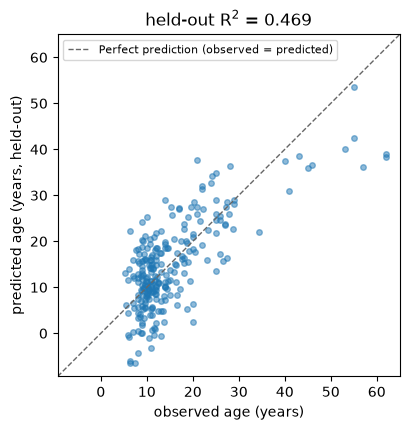

In [7]:
# 8. observed vs predicted on the test set, with the perfect-prediction diagonal.
fig, ax = plt.subplots(figsize=(4.4, 4.4))
lims = [min(y_test.min(), y_pred.min()) - 3, max(y_test.max(), y_pred.max()) + 3]
ax.plot(lims, lims, "--", color="0.4", lw=1, label="Perfect prediction (observed = predicted)")
ax.scatter(y_test, y_pred, s=16, alpha=0.5)
ax.set_xlim(lims); ax.set_ylim(lims); ax.set_aspect("equal")
ax.set_xlabel("observed age (years)"); ax.set_ylabel("predicted age (years, held-out)")
ax.set_title(f"held-out R$^2$ = {test_r2:.3f}")
ax.legend(loc="upper left", fontsize=8)
plt.tight_layout(); plt.show()


A few things to hold onto:

- the fitted model is a hyperplane in 360-dimensional feature space -- there is
  nothing useful to *draw* there. The observed-vs-predicted plot is the honest
  picture: points hugging the diagonal mean the model predicted well;
- this is a genuinely **positive held-out R²**: cortical thickness carries real
  information about age in this sample. A positive result is not automatically
  a *large* one -- read the number, not just its sign;
- this split estimates generalisation to **new participants from the same 17
  ABIDE-II sites**. A random participant split says nothing about how the model
  would do on an entirely new scanner or site.


```{admonition} Think first
:class: think-first
The test set here is a random 25% of participants, drawn from the *same* 17
sites, scanners, and protocols as the training set. Name one prediction task
this held-out score does **not** speak to.
```

```{dropdown} Check your reasoning
It does not estimate performance on a **new site or scanner** the model has
never seen. Sites differ in scanner hardware, sequences, and the people they
recruit; a model tuned on these 17 can lean on site-linked quirks that will not
transfer. A leave-one-site-out split would be needed to speak to that.
```


## 3. Three ways to score the same model

Same fixed split, same 360-feature recipe. Three numbers:

| | fit on | evaluate on | what it estimates |
|---|---|---|---|
| **A. Correct** | training rows | untouched test rows | performance on new participants |
| **B. Training score** | training rows | those same training rows | how well it fits data it has seen (a diagnostic, not a generalisation estimate) |
| **C. Invalid** | **test rows** | those same test rows | nothing usable -- the data used to fit cannot also give an honest score |

```{admonition} Think first
:class: think-first
Predict the order of the three R² values from largest to smallest, and say why.
```


In [8]:
# A: correct (already computed above) -> reuse `model`, `y_test`, `y_pred`.
# B: resubstitution
train_r2 = r2_score(y_train, model.predict(X_train))
train_mse = mean_squared_error(y_train, model.predict(X_train))

# C: a DELIBERATELY INVALID model -- fit on the test rows, scored on the same
# test rows. Named so it cannot be reused by accident. Note n_test (251) is
# SMALLER than n_features (360) here, so this fit is not just optimistic --
# it is underdetermined, and can match the 251 test points almost exactly.
invalid_test_fitted_model = make_pipeline(StandardScaler(), LinearRegression())
invalid_test_fitted_model.fit(X_test, y_test)
invalid_pred = invalid_test_fitted_model.predict(X_test)
invalid_r2 = r2_score(y_test, invalid_pred)
invalid_mse = mean_squared_error(y_test, invalid_pred)

scores = pd.DataFrame(
    {
        "fit on": ["training rows", "training rows", "test rows (INVALID)"],
        "evaluated on": ["test rows", "training rows", "same test rows"],
        "R^2": [test_r2, train_r2, invalid_r2],
        "MSE": [test_mse, train_mse, invalid_mse],
    },
    index=["A. correct", "B. training score", "C. invalid"],
)
print(f"n_train = {len(y_train)}   n_test = {len(y_test)}   n_features = {X.shape[1]}")
scores.round(3)


n_train = 753   n_test = 251   n_features = 360


,fit on,evaluated on,R^2,MSE
A. correct,training rows,test rows,0.469,49.554
B. training score,training rows,training rows,0.845,13.530
C. invalid,test rows (INVALID),same test rows,1.000,0.000


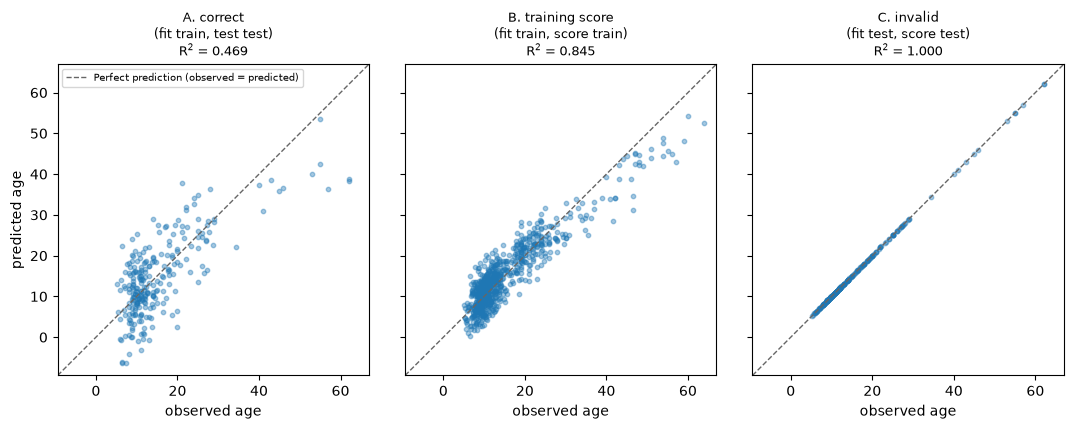

In [9]:
panels = [
    ("A. correct\n(fit train, test test)", y_test, y_pred, test_r2),
    ("B. training score\n(fit train, score train)", y_train, model.predict(X_train), train_r2),
    ("C. invalid\n(fit test, score test)", y_test, invalid_pred, invalid_r2),
]
allv = np.concatenate([y_train, y_test, y_pred, model.predict(X_train), invalid_pred])
lims = [allv.min() - 3, allv.max() + 3]
fig, axes = plt.subplots(1, 3, figsize=(11, 3.9), sharex=True, sharey=True)
for ax, (title, obs, pred, r2) in zip(axes, panels):
    ax.plot(lims, lims, "--", color="0.4", lw=1, label="Perfect prediction (observed = predicted)")
    ax.scatter(obs, pred, s=10, alpha=0.4)
    ax.set_xlim(lims); ax.set_ylim(lims); ax.set_aspect("equal")
    ax.set_title(f"{title}\nR$^2$ = {r2:.3f}", fontsize=9)
    ax.set_xlabel("observed age")
axes[0].set_ylabel("predicted age")
axes[0].legend(loc="upper left", fontsize=7)
plt.tight_layout(); plt.show()


- **B is not a competing model.** A high training R² next to a lower test R² is
  the signature of a model fitting some noise it cannot reproduce on new data.
- **C is not a competing model either.** With 360 features and only 251 test
  rows, `invalid_test_fitted_model` does not just look good -- it is
  **underdetermined** and reproduces those 251 points almost exactly, the same
  instability Section 5 discusses on purpose. Its R² is close to a perfect
  score by construction, not because it learned anything that generalises.
- B evaluates the model on its training data, whereas A and C are evaluated on
  the test data. A is the only valid estimate of performance on unseen
  participants; C is invalid because the test data were used for fitting.

```{dropdown} Check your reasoning: the ordering
C (invalid) > B (training) > A (correct). C is highest -- here essentially a
perfect fit -- because the same 251 rows picked the coefficients *and* graded
them, and with more features (360) than rows (251) the fit can match those
particular points almost exactly. B is next: the model saw these 753 rows while
fitting, so it reproduces them better than genuinely new rows. A is lowest
because the test rows had no influence on the coefficients at all -- it is the
only number that estimates anything about participants the model has not seen.
```


## 4. Comparing feature sets

Cortical structure changes with age across most of the brain, not in one
circumscribed system: large multi-site lifespan mapping (Bethlehem et al.,
2022,
[doi:10.1038/s41586-022-04554-y](https://doi.org/10.1038/s41586-022-04554-y))
and longitudinal work on adult cortical change (Storsve et al., 2014,
[doi:10.1523/JNEUROSCI.0391-14.2014](https://doi.org/10.1523/JNEUROSCI.0391-14.2014))
both describe widespread, region-varying change with age rather than change
confined to a small set of regions. So there is no single small region set
this exercise's own age literature prefers; the bundles below are used here
simply as several differently sized, differently located anatomical
comparisons.

The activity compares two models at a time on **one fixed cohort and one fixed
set of folds**, so any difference is a real difference between feature sets. It
shows out-of-sample scores only -- never training scores.


<iframe
  title="Interactive feature-set comparison for predicting age from brain structure"
  src="../../_static/widgets/app/index.html?config=../configs/regression_compare.json"
  loading="lazy"
  width="100%"
  height="1180"
  class="ml-activity"
  style="width: 100%;"
></iframe>


```{admonition} Think first
:class: think-first
1. Hold the ROI bundle fixed and change only the measurement type; then hold the
   measurement fixed and change only the bundle. Which control moves R² more?
2. Set one model to `All eligible ROIs`. What happens to the feature count and
   to R², and why -- and is that the same direction of change you would expect
   for a target with a much weaker brain-based signal than age?
3. Find the single best-scoring configuration you can. Would you trust its R²
   as your final reported number? Why or why not?
```

Trying many configurations is **exploratory model comparison**. If you pick the
best-looking one and quote its cross-validated R² as "the" performance, that
number is optimistic -- you chose it *because* it looked good on this data. A
locked test set or a nested procedure is needed for an honest final claim.


## 5. What does sample size change?

Sections 1-4 above used the full 360-parcel cortical-thickness recipe for
every model. Here, and only here, the feature set changes: to isolate what
growing the training set does to a model's stability and held-out accuracy,
this section deliberately holds a small, fixed, modest anatomical feature set
-- 10 cortical-thickness columns: primary motor cortex (BA4) plus primary
somatosensory cortex (BA 3a/3b/1/2), both hemispheres, the classic
sensorimotor strip -- instead of the whole-cortex set, and varies only the
number of training participants. `age`, the fixed held-out test set from
Section 2, and the model family (ordinary least squares with the same
explicit-scaling-then-pipeline recipe from Section 2) are unchanged.

This modest feature set was chosen in advance, before this section's own
held-out test score was ever examined: a short list of small, well-established
bilateral anatomical bundles (each at most 12 columns) was scored using only
the training partition, against a rule fixed before any candidate was
scored -- a clear upward trend in the typical held-out result as the training
size grows, instability that narrows materially, and a final result strong
enough to be worth plotting. This bundle was the first predeclared candidate
whose training-only result cleared that rule, not the smallest p or the
best-looking curve; the other candidates that were scored, including ones not
used here, are reported alongside this notebook.

The sizes below are fixed in advance and are comfortably larger than the
feature count throughout: `40, 60, 90, 130, 200, 300`, and the full training
set, `753`. Ordinary least squares is always well posed here -- `n_train`
never comes close to `p = 10` -- so this curve isolates sample size on its
own, without the whole-cortex recipe's own near-`n=p` instability (Section 2
keeps that recipe, and that instability, unchanged). Resample many times at
each size so the answer is about the *typical* outcome and its spread, not
one lucky or unlucky draw.


In [10]:
# The small, fixed cortical-thickness subset used ONLY for this section's
# isolated sample-size demonstration -- Sections 1-4 above keep the full
# 360-feature recipe throughout, unchanged. Primary motor cortex (BA4) plus
# primary somatosensory cortex (BA 3a/3b/1/2), bilateral: the classic
# sensorimotor strip.
SAMPLE_SIZE_ROIS = ["4", "3a", "3b", "1", "2"]
FEATURES_SS = [f"fsCT_{hemi}_{roi}_ROI" for roi in SAMPLE_SIZE_ROIS for hemi in ("L", "R")]
assert all(c in BRAIN_COLS for c in FEATURES_SS)              # real columns
assert all(c.startswith("fsCT_") for c in FEATURES_SS)        # brain-only
assert "age" not in FEATURES_SS                                # no target leakage
print(f"{len(FEATURES_SS)} features: {FEATURES_SS}")

# Reuse the SAME fixed, stratified split as Sections 1-4 (identical
# random_state, test_size, and stratify array) so this section's training and
# test participants are exactly the Section 2 ones, just described by fewer
# columns -- proven, not assumed, by the assertion below.
X_ss = model_df.loc[has_age, FEATURES_SS].to_numpy(float)
X_train_ss, X_test_ss, y_train_ss, y_test_ss = train_test_split(
    X_ss, y, test_size=0.25, random_state=42, stratify=groups
)
assert np.array_equal(y_train_ss, y_train) and np.array_equal(y_test_ss, y_test)
print(f"n_train = {len(y_train_ss)}   n_test = {len(y_test_ss)}   n_features (p) = {X_ss.shape[1]}")

rng = np.random.default_rng(0)
sizes = [40, 60, 90, 130, 200, 300, len(y_train_ss)]   # predeclared; always well above p (10)
n_rep = 40
lc_med_r2, lc_lo_r2, lc_hi_r2 = [], [], []
lc_med_mse, lc_lo_mse, lc_hi_mse = [], [], []
for n in sizes:
    r2_reps, mse_reps = [], []
    for _ in range(n_rep):
        idx = rng.choice(len(y_train_ss), size=min(n, len(y_train_ss)), replace=False)
        pipe = make_pipeline(StandardScaler(), LinearRegression()).fit(X_train_ss[idx], y_train_ss[idx])
        pred = pipe.predict(X_test_ss)
        r2_reps.append(r2_score(y_test_ss, pred))
        mse_reps.append(mean_squared_error(y_test_ss, pred))
    r2_reps, mse_reps = np.array(r2_reps), np.array(mse_reps)
    lc_med_r2.append(np.median(r2_reps)); lc_lo_r2.append(np.percentile(r2_reps, 10)); lc_hi_r2.append(np.percentile(r2_reps, 90))
    lc_med_mse.append(np.median(mse_reps)); lc_lo_mse.append(np.percentile(mse_reps, 10)); lc_hi_mse.append(np.percentile(mse_reps, 90))

print(f"n_features (p) = {X_ss.shape[1]}")
for n, mr2, lo, hi, mmse in zip(sizes, lc_med_r2, lc_lo_r2, lc_hi_r2, lc_med_mse):
    print(f"  n_train = {n:4d}  n/p = {n/X_ss.shape[1]:5.2f}   held-out R^2 median {mr2:+8.3f}   10-90 pct [{lo:+8.3f}, {hi:+8.3f}]   median MSE {mmse:8.1f}")


10 features: ['fsCT_L_4_ROI', 'fsCT_R_4_ROI', 'fsCT_L_3a_ROI', 'fsCT_R_3a_ROI', 'fsCT_L_3b_ROI', 'fsCT_R_3b_ROI', 'fsCT_L_1_ROI', 'fsCT_R_1_ROI', 'fsCT_L_2_ROI', 'fsCT_R_2_ROI']
n_train = 753   n_test = 251   n_features (p) = 10


n_features (p) = 10
  n_train =   40  n/p =  4.00   held-out R^2 median   +0.188   10-90 pct [  -0.040,   +0.300]   median MSE     75.8
  n_train =   60  n/p =  6.00   held-out R^2 median   +0.265   10-90 pct [  +0.156,   +0.348]   median MSE     68.6
  n_train =   90  n/p =  9.00   held-out R^2 median   +0.356   10-90 pct [  +0.244,   +0.395]   median MSE     60.1
  n_train =  130  n/p = 13.00   held-out R^2 median   +0.370   10-90 pct [  +0.317,   +0.405]   median MSE     58.8
  n_train =  200  n/p = 20.00   held-out R^2 median   +0.373   10-90 pct [  +0.349,   +0.402]   median MSE     58.5
  n_train =  300  n/p = 30.00   held-out R^2 median   +0.395   10-90 pct [  +0.363,   +0.413]   median MSE     56.5
  n_train =  753  n/p = 75.30   held-out R^2 median   +0.407   10-90 pct [  +0.407,   +0.407]   median MSE     55.4


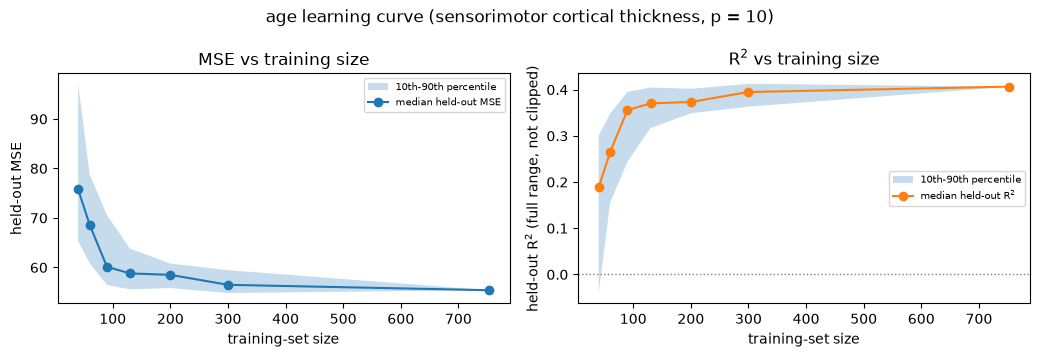

In [11]:
fig, (ax_mse, ax_r2) = plt.subplots(1, 2, figsize=(10.5, 3.6))

ax_mse.fill_between(sizes, lc_lo_mse, lc_hi_mse, alpha=0.25, label="10th-90th percentile")
ax_mse.plot(sizes, lc_med_mse, "o-", label="median held-out MSE")
ax_mse.set_xlabel("training-set size"); ax_mse.set_ylabel("held-out MSE")
ax_mse.set_title("MSE vs training size"); ax_mse.legend(fontsize=7)

ax_r2.fill_between(sizes, lc_lo_r2, lc_hi_r2, alpha=0.25, label="10th-90th percentile")
ax_r2.plot(sizes, lc_med_r2, "o-", color="C1", label="median held-out R$^2$")
ax_r2.axhline(0, color="0.5", lw=1, ls=":")
ax_r2.set_xlabel("training-set size"); ax_r2.set_ylabel("held-out R$^2$ (full range, not clipped)")
ax_r2.set_title("R$^2$ vs training size"); ax_r2.legend(fontsize=7)

fig.suptitle("age learning curve (sensorimotor cortical thickness, p = 10)")
plt.tight_layout(); plt.show()


```{admonition} What the learning curve shows -- and does not
:class: note
Median held-out R² climbs steadily as `n_train` grows, and the 10th-90th
percentile spread narrows sharply alongside it -- the honest, typical shape
for a fixed, modest feature set that is never close to `n_train` (every
plotted size is at least 4x `p = 10`). This is **not** a claim that more
data always helps on any single draw: at some neighbouring sizes an unlucky
sample can still score worse than a lucky one at a slightly smaller size --
read the *median trend and the narrowing band*, not any one repeat.

This curve looks nothing like Section 2's whole-cortex (`p = 360`) recipe
would if swept the same way: that recipe's own sample-size behaviour near
`n_train = p` is a real, separate, more advanced phenomenon (documented in
the audit behind this notebook, not shown here) that this section's much
smaller, fixed feature set exists specifically to avoid, so that training-set
size alone is easy to see.
```


## In summary

- An honest performance estimate fits on training data and scores on data the
  model has never seen. Scoring on the fitting rows -- whether they are the
  training set (optimistic) or, worse, the test set (invalid, and here
  literally underdetermined) -- inflates the number.
- `age` has a genuinely positive held-out R² from cortical structure alone.
- Scaling features before fitting does not change unregularised linear
  regression's predictions, but writing the steps out explicitly (Section 2)
  builds the training-only-fitting habit that matters greatly for
  distance-based methods like the next practice's k-nearest neighbours.
- Holding a small, fixed feature set and varying only the training-set size
  (Section 5) shows sample size on its own: the typical held-out score rises
  and its spread narrows as `n_train` grows, even though any one repeated
  sample can still land above or below that trend by chance.

Next practice: k-nearest neighbours, and the bias-variance tradeoff.


### Questions to take away

1. For this table, which columns are the outcome and which are the features?
2. Why does fitting and scoring a model on the *same* observations inflate its
   apparent performance? In Section 3, why is `invalid_test_fitted_model`'s
   score close to a perfect score rather than just "somewhat inflated"?
3. Section 2 gets a *positive* held-out R² for `age`. What would a *negative*
   one have meant instead?
4. In Section 2, why does the explicit-scaling cell give the exact same R² and
   MSE as the pipeline-shortcut cell? Name one kind of model where that would
   **not** be true.
5. Two feature sets in Section 4 give different cross-validated R². List three
   reasons other than "one set is biologically better" that could explain the
   gap.
6. Section 5 uses a much smaller feature set than Sections 1-4. Name one thing
   in the plot, other than the median line itself, that tells you the rising
   trend is real and not one lucky run.
7. In the learning curve, what improves as the training set grows from 300 to
   753, and what would you need to check before trusting the `n_train = 40`
   point just because one run's score happened to look good?
